<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                30 non-null     int64 
 1   Salary             30 non-null     int64 
 2   Tenure             30 non-null     int64 
 3   Overtime           30 non-null     object
 4   JobSatisfaction    30 non-null     int64 
 5   PerformanceRating  30 non-null     int64 
 6   Attrition          30 non-null     object
dtypes: int64(5), object(2)
memory usage: 1.8+ KB
Features:
   Age  Salary  Tenure  Overtime  JobSatisfaction  PerformanceRating
0   25   30000       1         1                2                  3
1   32   50000       5         0                4                  4
2   28   35000       2         1                2                  3
3   45   80000      10         0                5                  5
4   36   60000       6         0                4                  4



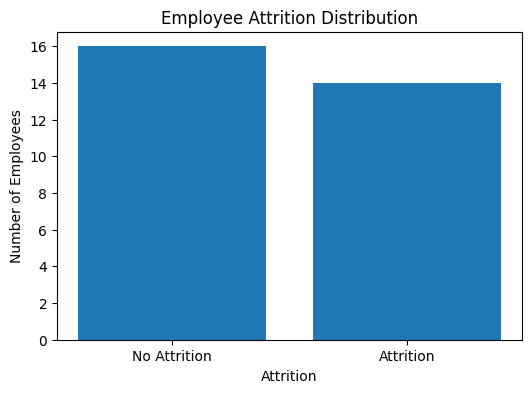

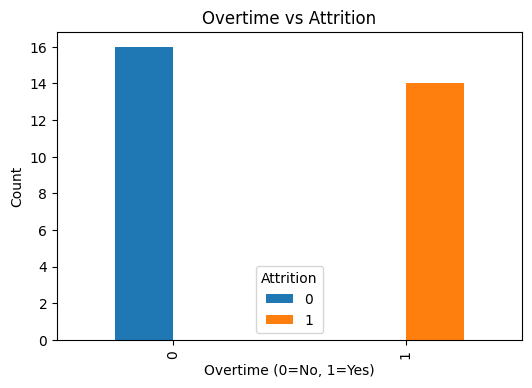

Prediction: This employee is likely to leave the company.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
#Cell 1:  Dataset Description
#We will create a simple HR dataset with the following columns:
#Age → Employee age
#Salary → Monthly salary
#Tenure → Number of years in company
#Overtime → Yes/No
#JobSatisfaction → Scale from 1 to 5
#PerformanceRating → Scale from 1 to 5
#Attrition → Yes/No (Target column)



#Cell 2: Create the HR dataset
# Create a sample HR dataset

data = {
    "Age": [25, 32, 28, 45, 36, 29, 41, 31, 27, 38,
            26, 34, 30, 42, 39, 24, 35, 37, 33, 40,
            29, 28, 46, 43, 27, 31, 36, 44, 30, 38],

    "Salary": [30000, 50000, 35000, 80000, 60000, 40000, 75000, 48000, 32000, 67000,
               31000, 52000, 45000, 82000, 71000, 29000, 58000, 65000, 49000, 76000,
               42000, 36000, 85000, 79000, 34000, 47000, 61000, 83000, 44000, 69000],

    "Tenure": [1, 5, 2, 10, 6, 3, 9, 4, 2, 7,
               1, 5, 3, 11, 8, 1, 6, 7, 4, 9,
               3, 2, 12, 10, 2, 4, 6, 11, 3, 8],

    "Overtime": ["Yes", "No", "Yes", "No", "No", "Yes", "No", "Yes", "Yes", "No",
                 "Yes", "No", "Yes", "No", "No", "Yes", "No", "No", "Yes", "No",
                 "Yes", "Yes", "No", "No", "Yes", "Yes", "No", "No", "Yes", "No"],

    "JobSatisfaction": [2, 4, 2, 5, 4, 3, 5, 2, 2, 4,
                        1, 4, 3, 5, 4, 1, 4, 5, 3, 5,
                        2, 2, 5, 4, 2, 3, 4, 5, 3, 4],

    "PerformanceRating": [3, 4, 3, 5, 4, 3, 5, 3, 2, 4,
                          2, 4, 3, 5, 4, 2, 4, 5, 3, 5,
                          3, 3, 5, 4, 2, 3, 4, 5, 3, 4],

    "Attrition": ["Yes", "No", "Yes", "No", "No", "Yes", "No", "Yes", "Yes", "No",
                  "Yes", "No", "Yes", "No", "No", "Yes", "No", "No", "Yes", "No",
                  "Yes", "Yes", "No", "No", "Yes", "Yes", "No", "No", "Yes", "No"]
}

df = pd.DataFrame(data)

# Display first 5 rows
df.head()

#Cell 3: View the complete dataset
# Display the full dataset
df


#Cell 4: Check dataset information
# Check data types and non-null values
df.info()


#Cell 5: Check for missing values
# Check if there are any missing values
df.isnull().sum()


#Cell 6: Basic statistical summary
# Display summary statistics for numerical columns
df.describe()

from sklearn.preprocessing import LabelEncoder
#Cell 7: Encode categorical columns
# Convert categorical text values into numeric values

le_overtime = LabelEncoder()
le_attrition = LabelEncoder()

df["Overtime"] = le_overtime.fit_transform(df["Overtime"])   # No=0, Yes=1
df["Attrition"] = le_attrition.fit_transform(df["Attrition"]) # No=0, Yes=1

# Display updated dataset
df.head()


#Cell 8: Separate features and target
# Separate input features (X) and target variable (y)

X = df[["Age", "Salary", "Tenure", "Overtime", "JobSatisfaction", "PerformanceRating"]]
y = df["Attrition"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

from sklearn.model_selection import train_test_split
#Cell 9: Split data into training and testing sets
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

from sklearn.tree import DecisionTreeClassifier
#Cell 10: Train the Decision Tree model
# Create and train the model

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

print("Model training completed successfully.")


#Cell 11: Make predictions
# Predict attrition for test data

y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

from sklearn.metrics import accuracy_score
#Cell 12: Evaluate model accuracy
# Check the accuracy of the model

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

from sklearn.metrics import confusion_matrix
#Cell 13: Confusion matrix
# Display confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

from sklearn.metrics import classification_report
#Cell 14: Classification report
# Detailed model performance report

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

import matplotlib.pyplot as plt
#Cell 15: Visualize attrition distribution
# Plot attrition distribution

attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(attrition_counts.index, attrition_counts.values)
plt.xticks([0, 1], ["No Attrition", "Attrition"])
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()


#Cell 16: Visualize overtime vs attrition
# Compare overtime and attrition

overtime_attrition = pd.crosstab(df["Overtime"], df["Attrition"])

overtime_attrition.plot(kind="bar", figsize=(6,4))
plt.title("Overtime vs Attrition")
plt.xlabel("Overtime (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()


#Cell 17: Predict attrition for a new employee
# Predict attrition for a new employee
# Feature order:
# Age, Salary, Tenure, Overtime, JobSatisfaction, PerformanceRating

new_employee = [[28, 35000, 2, 1, 2, 3]]

prediction = model.predict(new_employee)

if prediction[0] == 1:
    print("Prediction: This employee is likely to leave the company.")
else:
    print("Prediction: This employee is likely to stay in the company.")